In [224]:
import numpy as np
import polars as pl
import seaborn as sns

In [225]:
infpath = '/mnt/data/Max/repos/reverlor/param_selection/test_repeat_detection/data/find_repeats_results/merged.tsv'

In [226]:
df = pl.read_csv(infpath, separator='\t')

In [227]:
df = df.with_columns(
    (
        pl.col('repeat_len').cast(pl.String) \
        + '_' \
        + pl.col('repeat_idx').cast(pl.String) \
        + '_' \
        + pl.col('rate').cast(pl.String) \
    ).alias('repeat_id')
)

In [228]:
df.head()

repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,repeat_id
i64,i64,f64,str,i64,i64,str
10000,0,0.0,"""true""",241716,251716,"""10000_0_0.0"""
10000,0,0.0,"""true""",284151,294151,"""10000_0_0.0"""
10000,0,0.0,"""pred""",241716,251717,"""10000_0_0.0"""
10000,0,0.0,"""pred""",284150,294151,"""10000_0_0.0"""
10000,0,0.01,"""true""",241716,251716,"""10000_0_0.01"""


In [229]:
true_df = df.filter(
    pl.col('value_type') == 'true'
)
pred_df = df.filter(
    pl.col('value_type') == 'pred'
)

In [230]:
true_df.shape

(2240, 7)

In [231]:
pred_df.shape

(492, 7)

In [232]:
true_df.filter(pl.col('rate') == 0.0).head()

repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,repeat_id
i64,i64,f64,str,i64,i64,str
10000,0,0.0,"""true""",241716,251716,"""10000_0_0.0"""
10000,0,0.0,"""true""",284151,294151,"""10000_0_0.0"""
10000,1,0.0,"""true""",191496,201496,"""10000_1_0.0"""
10000,1,0.0,"""true""",334059,344059,"""10000_1_0.0"""
10000,2,0.0,"""true""",132947,142947,"""10000_2_0.0"""


In [233]:
tyk_repeat_id = '10000_0_0.0'

In [234]:
true_df.filter(
    (pl.col('repeat_id') == tyk_repeat_id)
)

repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,repeat_id
i64,i64,f64,str,i64,i64,str
10000,0,0.0,"""true""",241716,251716,"""10000_0_0.0"""
10000,0,0.0,"""true""",284151,294151,"""10000_0_0.0"""


In [235]:
pred_df.filter(
    (pl.col('repeat_id') == tyk_repeat_id)
)

repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,repeat_id
i64,i64,f64,str,i64,i64,str
10000,0,0.0,"""pred""",241716,251717,"""10000_0_0.0"""
10000,0,0.0,"""pred""",284150,294151,"""10000_0_0.0"""


In [236]:
pred_df.filter(
    (pl.col('repeat_id') == tyk_repeat_id) \
  & ( (pl.col('start_coord') - 510209).abs() < 10 ) \
  & ( (pl.col('end_coord')   - 520209).abs() < 10 )
)

repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,repeat_id
i64,i64,f64,str,i64,i64,str


In [237]:
pred_df.filter(
    (pl.col('repeat_id') == tyk_repeat_id) \
  & ( (pl.col('start_coord') - 483432).abs() < 10 ) \
  & ( (pl.col('end_coord')   - 493432).abs() < 10 )
)

repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,repeat_id
i64,i64,f64,str,i64,i64,str


In [238]:
all_repeat_ids = frozenset(
    true_df['repeat_id']
)

In [239]:
MAX_ERROR_BP = 10

In [240]:
repeat_id_list = list()
repeat_start_coord_list = list()
repeat_found_list = list()

for repeat_id in all_repeat_ids:
    curr_true_df = true_df.filter(pl.col('repeat_id') == repeat_id)
    curr_pred_df = pred_df.filter(pl.col('repeat_id') == repeat_id)

    for true_row in curr_true_df.to_dicts():
        curr_pred_detect_df = curr_pred_df.filter(
            (pl.col('repeat_id') == repeat_id) \
          & ( (pl.col('start_coord') - true_row['start_coord']).abs() <= MAX_ERROR_BP ) \
          & ( (pl.col('end_coord')   - true_row['end_coord']).abs() <= MAX_ERROR_BP )
        )

        found_value = 0
        if curr_pred_detect_df.shape[0] > 0:
            found_value = 1
        # end if

        repeat_id_list.append(repeat_id)
        repeat_start_coord_list.append(true_row['start_coord'])
        repeat_found_list.append(found_value)
    # end for
# end for

In [241]:
print(len(repeat_id_list))
print(len(repeat_start_coord_list))
print(len(repeat_found_list))

repeat_detect_df = pl.DataFrame({
    'repeat_id': repeat_id_list,
    'repeat_start_coord': repeat_start_coord_list,
    'repeat_detected': repeat_found_list,
})

2240
2240
2240


In [242]:
repeat_detect_df.shape

(2240, 3)

In [243]:
assert repeat_detect_df.shape[0] == true_df.shape[0]

In [244]:
repeat_detect_df = repeat_detect_df.join(
    true_df,
    on='repeat_id',
    how='inner'
).select(
    pl.col('repeat_id', 'repeat_start_coord', 'repeat_detected', 'repeat_len', 'repeat_idx', 'rate')
).unique()

In [245]:
repeat_detect_df.shape

(2240, 6)

In [246]:
repeat_detect_df.head()

repeat_id,repeat_start_coord,repeat_detected,repeat_len,repeat_idx,rate
str,i64,i64,i64,i64,f64
"""5000_1_0.08""",66553,0,5000,1,0.08
"""1000_9_0.14""",263311,0,1000,9,0.14
"""500_7_0.0""",33653,1,500,7,0.0
"""5000_0_0.09""",103540,0,5000,0,0.09
"""5000_9_0.07""",201101,0,5000,9,0.07


In [247]:
N_repeats = true_df.filter(
    (pl.col('repeat_len') == 200) \
    & (pl.col('rate') == 0.0)
).shape[0]
print('N_repeats = {}'.format(N_repeats))

per_rate_len_summary_df = repeat_detect_df.group_by('rate', 'repeat_len').agg(
    pl.col('repeat_detected').sum().alias('repeat_detected_count')
).sort(by=['rate', 'repeat_len'])

per_rate_len_summary_df = per_rate_len_summary_df.with_columns(
    (pl.col('repeat_detected_count') / N_repeats * 100.0).alias('repeat_detected_percent')
)

per_rate_len_summary_df.head(10)

N_repeats = 20


rate,repeat_len,repeat_detected_count,repeat_detected_percent
f64,i64,i64,f64
0.0,127,0,0.0
0.0,200,20,100.0
0.0,500,20,100.0
0.0,1000,19,95.0
0.0,3000,20,100.0
0.0,5000,20,100.0
0.0,10000,20,100.0
0.01,127,0,0.0
0.01,200,2,10.0


In [248]:
N_repeats = true_df.filter(
    pl.col('rate') == 0.0
).shape[0]
print('N_repeats = {}'.format(N_repeats))

per_rate_summary_df = repeat_detect_df.group_by('rate').agg(
    pl.col('repeat_detected').sum().alias('repeat_detected_count')
).sort(by=['rate'])

per_rate_summary_df = per_rate_summary_df.with_columns(
    (pl.col('repeat_detected_count') / N_repeats * 100.0).alias('repeat_detected_percent')
)

per_rate_summary_df.head(10)

N_repeats = 140


rate,repeat_detected_count,repeat_detected_percent
f64,i64,f64
0.0,119,85.0
0.01,98,70.0
0.02,82,58.571429
0.03,68,48.571429
0.04,40,28.571429
0.05,20,14.285714
0.06,1,0.714286
0.07,0,0.0
0.08,0,0.0


In [256]:
N_repeats = true_df.filter(
    (pl.col('repeat_len') == 127) \
    & (pl.col('rate') == 0.0)
).shape[0]
print('N_repeats = {}'.format(N_repeats))

per_rate_len127_summary_df = repeat_detect_df.filter(
    pl.col('repeat_len') == 127
).group_by('rate').agg(
    pl.col('repeat_detected').sum().alias('repeat_detected_count')
).sort(by=['rate'])

per_rate_len127_summary_df = per_rate_len127_summary_df.with_columns(
    (pl.col('repeat_detected_count') / N_repeats * 100.0).alias('repeat_detected_percent')
)

per_rate_len127_summary_df.head(10)

N_repeats = 20


rate,repeat_detected_count,repeat_detected_percent
f64,i64,f64
0.0,0,0.0
0.01,0,0.0
0.02,0,0.0
0.03,0,0.0
0.04,0,0.0
0.05,0,0.0
0.06,0,0.0
0.07,0,0.0
0.08,0,0.0


In [249]:
N_repeats = true_df.filter(
    (pl.col('repeat_len') == 200) \
    & (pl.col('rate') == 0.0)
).shape[0]
print('N_repeats = {}'.format(N_repeats))

per_rate_len200_summary_df = repeat_detect_df.filter(
    pl.col('repeat_len') == 200
).group_by('rate').agg(
    pl.col('repeat_detected').sum().alias('repeat_detected_count')
).sort(by=['rate'])

per_rate_len200_summary_df = per_rate_len200_summary_df.with_columns(
    (pl.col('repeat_detected_count') / N_repeats * 100.0).alias('repeat_detected_percent')
)

per_rate_len200_summary_df.head(10)

N_repeats = 20


rate,repeat_detected_count,repeat_detected_percent
f64,i64,f64
0.0,20,100.0
0.01,2,10.0
0.02,0,0.0
0.03,0,0.0
0.04,0,0.0
0.05,0,0.0
0.06,0,0.0
0.07,0,0.0
0.08,0,0.0


In [254]:
N_repeats = true_df.filter(
    (pl.col('repeat_len') == 10000) \
    & (pl.col('rate') == 0.0)
).shape[0]
print('N_repeats = {}'.format(N_repeats))

per_rate_len10000_summary_df = repeat_detect_df.filter(
    pl.col('repeat_len') == 10000
).group_by('rate').agg(
    pl.col('repeat_detected').sum().alias('repeat_detected_count')
).sort(by=['rate'])

per_rate_len10000_summary_df = per_rate_len10000_summary_df.with_columns(
    (pl.col('repeat_detected_count') / N_repeats * 100.0).alias('repeat_detected_percent')
)

per_rate_len200_summary_df.head(10)

N_repeats = 20


rate,repeat_detected_count,repeat_detected_percent
f64,i64,f64
0.0,20,100.0
0.01,2,10.0
0.02,0,0.0
0.03,0,0.0
0.04,0,0.0
0.05,0,0.0
0.06,0,0.0
0.07,0,0.0
0.08,0,0.0


<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

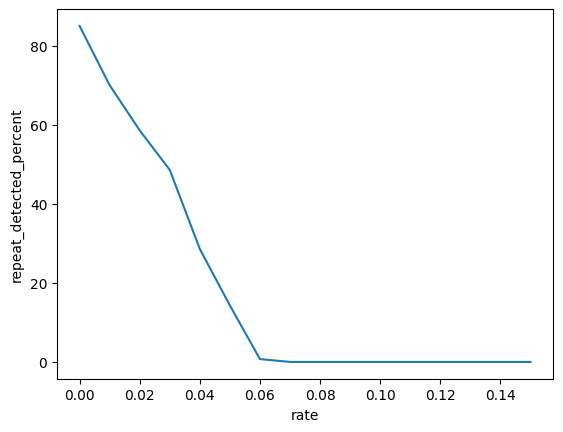

In [251]:
sns.lineplot(
    per_rate_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

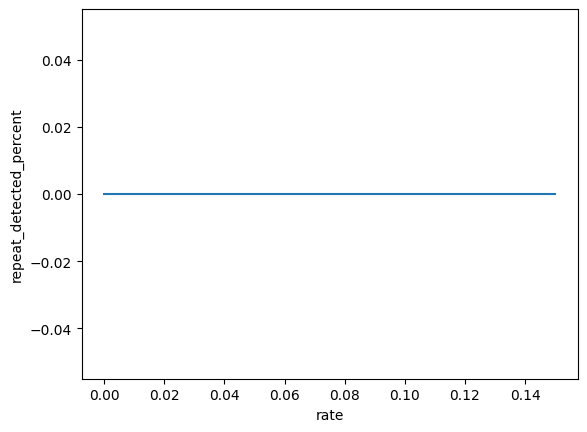

In [257]:
sns.lineplot(
    per_rate_len127_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

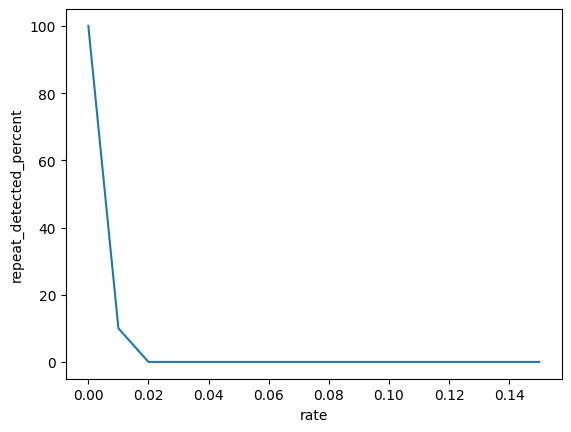

In [252]:
sns.lineplot(
    per_rate_len200_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

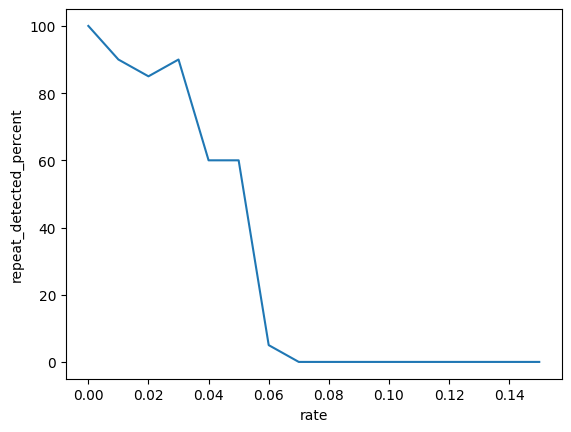

In [255]:
sns.lineplot(
    per_rate_len10000_summary_df,
    x='rate',
    y='repeat_detected_percent'
)